In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import os
import sys
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import ollama


sys.path.append(os.path.abspath('..')) 


from src.processing.nlp_extractors import ScholarshipDataProcessor


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


tqdm.pandas(desc="Processing NLP Pipeline")

In [2]:
print(">>> Loading Raw Data...")
all_data = []

folder_path = '../data_Json' 

file_paths = glob.glob(os.path.join(folder_path, '*_scholarships_data*.json'))
for file_path in file_paths:
    try:
        df_temp = pd.read_json(file_path)
        df_temp['source_file'] = os.path.basename(file_path)
        all_data.append(df_temp)
    except Exception as e:
        print(f"Error loading {os.path.basename(file_path)}: {e}")

df_raw = pd.concat(all_data, ignore_index=True)
print(f" Total records loaded: {len(df_raw)}")
df_raw.head(2)

>>> Loading Raw Data...
 Total records loaded: 2526


,scholarship_name,country,degree_level,funding_type,awards_available,deadline,tags,description,scholarship_details,eligibility,application_process,application_link,source_file
0,First Presbyterian Church of Shreveport Schola...,USA,Theology/Ministry,Amount Varies,Varies,"May 15, 2026","[State Selection, Religious Affiliation, Selec...","First Presbyterian Church offers an annual, no...","Annual, non-renewable scholarship for seminary...",Affiliation with the Presbyterian Church (USA)...,Obtain the scholarship application form from F...,https://www.scholarships.com/scholarships/firs...,theology_scholarships_data.json
1,Lucile Murray Durkin Scholarship,USA,Theology/Ministry,"$2,200",Varies,"May 15, 2026","[Gender, Religious Affiliation, Selected Major...","This unique scholarship awards $2,200 to women...",Supports women and non-binary people\nAwards n...,Primarily for female or non-binary wishing to ...,"Submit an essay (1,000 words), original artwor...",https://www.scholarships.com/scholarships/luci...,theology_scholarships_data.json


### funding_type & degree_level	

In [4]:
print(">>> Initializing the NLP Processor (This might take a moment to load spaCy)...")
processor = ScholarshipDataProcessor(use_zero_shot=False) # اجعلها True إذا كان جهازك يتحمل

print(">>> Extracting Funding Data...")
df_raw[['funding_category', 'funding_amount']] = df_raw.progress_apply(processor.process_funding, axis=1)

print(">>> Extracting Degree Levels & Majors...")
df_raw[['academic_major', 'academic_level']] = df_raw.progress_apply(processor.process_degree_level, axis=1)

print("Processing Complete!")

INFO: Initializing NLP Models...


>>> Initializing the NLP Processor (This might take a moment to load spaCy)...
>>> Extracting Funding Data...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

>>> Extracting Degree Levels & Majors...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

Processing Complete!


In [5]:
total_rows = len(df_raw)


unspecified_level = (df_raw['academic_level'] == 'Unspecified').sum()
unspecified_funding = (df_raw['funding_category'] == 'Variable / Unspecified').sum()

print("--- Extraction Quality Report ---")
print(f"Total Processed: {total_rows}")
print(f"Academic Level Extraction Failure: {unspecified_level} records ({(unspecified_level/total_rows)*100:.1f}%)")
print(f"Funding Category Extraction Failure: {unspecified_funding} records ({(unspecified_funding/total_rows)*100:.1f}%)")


if unspecified_level > 0:
    print("\n--- Sample of Failed Academic Levels (Needs Regex tuning) ---")
    display(df_raw[df_raw['academic_level'] == 'Unspecified'][['scholarship_name', 'description']].head())

--- Extraction Quality Report ---
Total Processed: 2526
Academic Level Extraction Failure: 169 records (6.7%)
Funding Category Extraction Failure: 166 records (6.6%)

--- Sample of Failed Academic Levels (Needs Regex tuning) ---


,scholarship_name,description
0,International Titanium Association Scholarship...,"The International Titanium Association, a non-..."
5,Reason One Mentorship and Scholarship Program,The Reason One Mentorship & Scholarship Progra...
7,Betty Stevens-Frecknall Scholarship,The Betty Stevens-Frecknall Scholarship is a p...
10,Project STEM Heroes Scholarship,"""You are the solution."" Inspired by the movie ..."
12,SBB Research Group STEM Scholarship,The SBB Research Group STEM Scholarship encour...


C:\Users\shaza\AppData\Local\Temp\ipykernel_3632\1785376926.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='academic_level', ax=axes[0], palette="viridis", order=df_raw['academic_level'].value_counts().index)
C:\Users\shaza\AppData\Local\Temp\ipykernel_3632\1785376926.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw[df_raw['academic_major'].isin(top_majors)], y='academic_major', ax=axes[1], palette="magma", order=top_majors)
C:\Users\shaza\AppData\Local\Temp\ipykernel_3632\1785376926.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` f

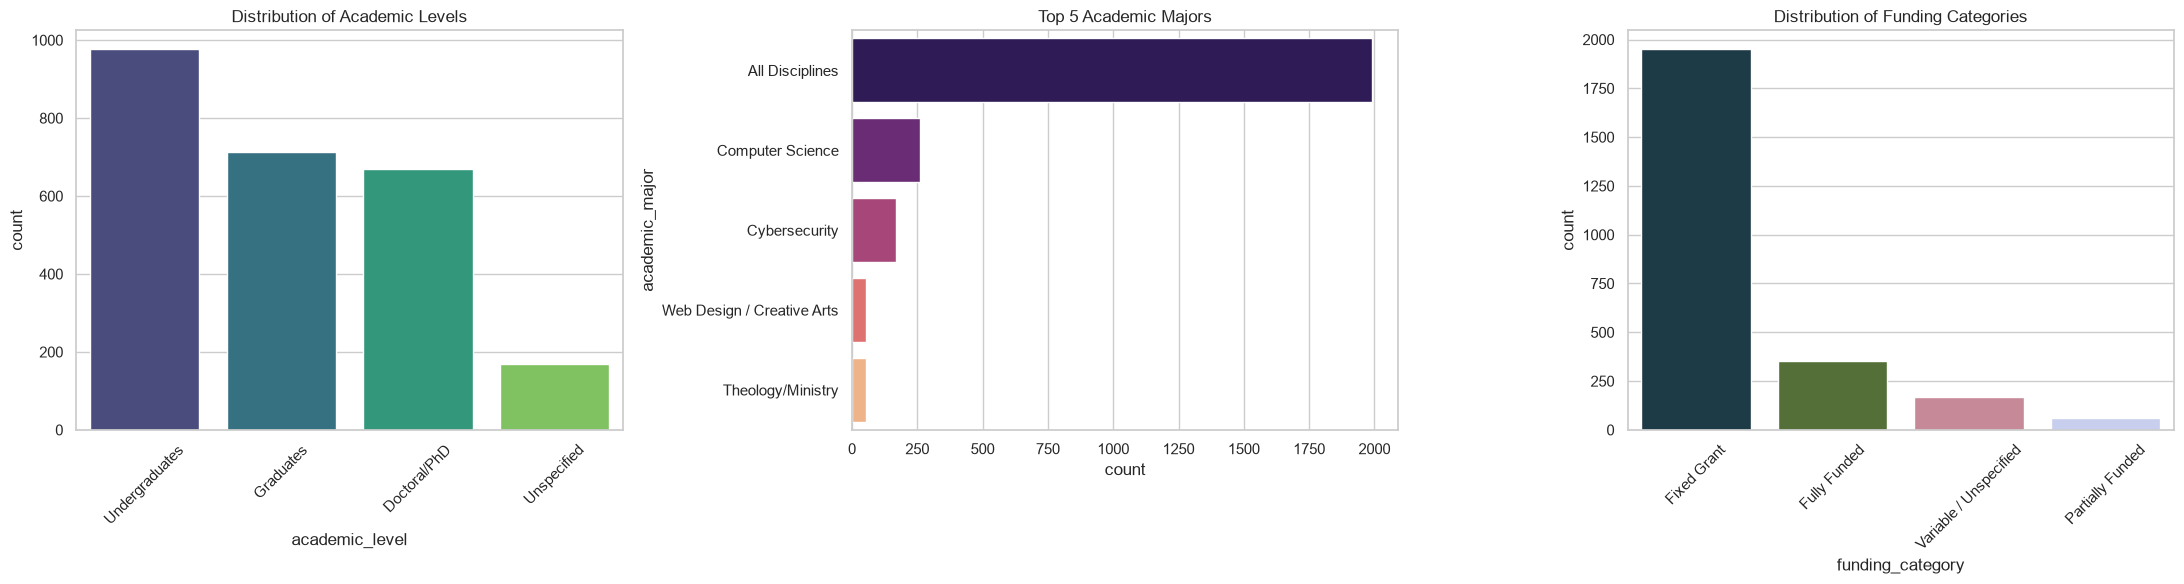

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))


sns.countplot(data=df_raw, x='academic_level', ax=axes[0], palette="viridis", order=df_raw['academic_level'].value_counts().index)
axes[0].set_title('Distribution of Academic Levels')
axes[0].tick_params(axis='x', rotation=45)


top_majors = df_raw['academic_major'].value_counts().nlargest(5).index
sns.countplot(data=df_raw[df_raw['academic_major'].isin(top_majors)], y='academic_major', ax=axes[1], palette="magma", order=top_majors)
axes[1].set_title('Top 5 Academic Majors')


sns.countplot(data=df_raw, x='funding_category', ax=axes[2], palette="cubehelix", order=df_raw['funding_category'].value_counts().index)
axes[2].set_title('Distribution of Funding Categories')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
print("--- 1. Academic Level Distribution ---")

level_dist = df_raw['academic_level'].value_counts()
level_pct = df_raw['academic_level'].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({'Count': level_dist, 'Percentage %': level_pct.round(2)})
display(dist_df)

print("\n--- 2. Funding Category Distribution ---")

funding_dist = df_raw['funding_category'].value_counts()
funding_pct = df_raw['funding_category'].value_counts(normalize=True) * 100
dist_funding_df = pd.DataFrame({'Count': funding_dist, 'Percentage %': funding_pct.round(2)})
display(dist_funding_df)

--- 1. Academic Level Distribution ---


,Count,Percentage %
academic_level,,
Undergraduates,976,38.64
Graduates,712,28.19
Doctoral/PhD,669,26.48
Unspecified,169,6.69



--- 2. Funding Category Distribution ---


,Count,Percentage %
funding_category,,
Fixed Grant,1949,77.16
Fully Funded,351,13.90
Variable / Unspecified,166,6.57
Partially Funded,60,2.38


In [13]:
print("--- QA: Academic Level Extraction Verification ---")

valid_levels = df_raw[df_raw['academic_level'] != 'Unspecified'].copy()


sample_levels = valid_levels.sample(frac=1, random_state=42).groupby('academic_level').head(20)


display(sample_levels[['scholarship_name', 'description', 'academic_level', 'academic_major','tags']])

print("\n--- QA: Funding Extraction Verification ---")

valid_funding = df_raw[df_raw['funding_category'] != 'Variable / Unspecified'].copy()


sample_funding = valid_funding.sample(frac=1, random_state=42).groupby('funding_category').head(10)


display(sample_funding[['funding_type', 'funding_category', 'funding_amount']])

--- QA: Academic Level Extraction Verification ---


,scholarship_name,description,academic_level,academic_major,tags
1771,European Union: Erasmus+ Mobility Programme fo...,---\nProgramme Description\n---\nErasmus+ mobi...,Graduates,All Disciplines,"[DAAD, Saudi Arabia, Graduates, Germany]"
1194,German Bundestag: International Parliamentary ...,---\nProgramme Description\n---\nUp to 120 spo...,Undergraduates,All Disciplines,"[DAAD, Saudi Arabia, Undergraduates, Germany]"
1725,RWTH International Academy: Women in Engineeri...,---\nProgramme Description\n---\nThis scholars...,Undergraduates,All Disciplines,"[DAAD, Egypt, Undergraduates, Germany]"
2243,Göttingen Academy of Sciences and Humanities: ...,---\nProgramme Description\n---\nThe Hannah Ar...,Doctoral/PhD,All Disciplines,"[DAAD, Egypt, Doctoral candidates/PhD students..."
242,Boeing Engineering Internship Program,"At Boeing, we innovate and collaborate to make...",Undergraduates,Computer Science,"[GPA, Selected Major(s), Current Year in Schoo..."
1919,Fulbright Commission: Fulbright Programme (Egy...,---\nProgramme Description\n---\nThe Fulbright...,Doctoral/PhD,All Disciplines,"[DAAD, Egypt, Doctoral candidates/PhD students..."
1258,Gerda Henkel Foundation: PhD Scholarships (Egy...,---\nProgramme Description\n---\nThe PhD schol...,Graduates,All Disciplines,"[DAAD, Egypt, Graduates, Germany]"
553,In-Country/In Region Scholarships Programme at...,"The programme aims at fostering strong, intern...",Graduates,All Disciplines,"[DAAD, Syria, Graduates, Germany]"
1776,Combined study and practical stays for enginee...,Advanced students of engineering sciences of t...,Undergraduates,All Disciplines,"[DAAD, Syria, Undergraduates, Germany]"
1604,Evonik Foundation: Evonik Foundation Scholarsh...,---\nProgramme Description\n---\nResearch work...,Doctoral/PhD,All Disciplines,"[DAAD, Saudi Arabia, Doctoral candidates/PhD s..."



--- QA: Funding Extraction Verification ---


,funding_type,funding_category,funding_amount
655,Fully/Partially Funded (Check Details),Fixed Grant,1.400 eur
534,Fully/Partially Funded (Check Details),Fixed Grant,600 eur
2373,Fully/Partially Funded (Check Details),Fully Funded,NaN
2106,Fully/Partially Funded (Check Details),Fixed Grant,992 eur
1675,Fully/Partially Funded (Check Details),Fully Funded,NaN
228,"$3,000",Fixed Grant,"$3,000"
1694,Fully/Partially Funded (Check Details),Fixed Grant,992 eur
270,"$1,500",Fixed Grant,"$1,500"
1228,Fully/Partially Funded (Check Details),Fixed Grant,"1,750 eur"
702,Fully/Partially Funded (Check Details),Fixed Grant,600 eur


### country

In [9]:
print(">>> Extracting Host Countries and Eligible Nationalities...")
df_raw[['host_country', 'eligible_nationality']] = df_raw.progress_apply(processor.process_country, axis=1)
print("Extraction Complete!")

>>> Extracting Host Countries and Eligible Nationalities...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

Extraction Complete!


In [10]:
total_rows = len(df_raw)

# Calculate missing or default values
unspecified_host = (df_raw['host_country'] == 'Unspecified').sum()
international_nat = (df_raw['eligible_nationality'] == 'International / All').sum()

print("--- Location Extraction Quality Report ---")
print(f"Total Processed: {total_rows}")
print(f"Host Country Not Found (Unspecified): {unspecified_host} records ({(unspecified_host/total_rows)*100:.1f}%)")
print(f"Eligible Nationality (Defaulted to International): {international_nat} records ({(international_nat/total_rows)*100:.1f}%)")

# Display a sample of records where host country failed
if unspecified_host > 0:
    print("\n--- Sample of Failed Host Country Extractions ---")
    display(df_raw[df_raw['host_country'] == 'Unspecified'][['scholarship_name', 'country', 'description']].head())

--- Location Extraction Quality Report ---
Total Processed: 2526
Host Country Not Found (Unspecified): 0 records (0.0%)
Eligible Nationality (Defaulted to International): 488 records (19.3%)


In [11]:
print("--- QA: Host Country and Nationality Verification ---")

# Filter out rows where host country is unspecified to verify successful extractions
valid_locations = df_raw[df_raw['host_country'] != 'Germany'].copy()

# Take a randomized sample grouped by host country
sample_locations = valid_locations.sample(frac=1, random_state=42).groupby('host_country').head(10)

# Display the raw country column alongside the extracted features
display(sample_locations[['scholarship_name', 'country', 'host_country', 'eligible_nationality']].head(15))

--- QA: Host Country and Nationality Verification ---


,scholarship_name,country,host_country,eligible_nationality
222,Hedy Lamarr Achievement Award,USA,USA,International / All
131,Asama Coldwater Manufacturing (ACM) Georgia Sc...,USA,USA,International / All
149,PG&E Better Together STEM Scholarship Program,USA,USA,International / All
244,Center for Women In Technology (CWIT) Scholars...,USA,USA,International / All
84,Quad City Engineering and Science Council Scho...,USA,USA,International / All
376,U.S. Western Digital STEM Scholarship,USA,USA,International / All
6,Kathy Pace Technology Scholarship,USA,USA,International / All
2468,TEDS Faithful Future Scholarship,USA,USA,International / All
2508,BHW Scholarship,USA,USA,International / All
55,National Defense Science & Engineering Graduat...,USA,USA,International / All


C:\Users\shaza\AppData\Local\Temp\ipykernel_3632\3365733669.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hosts.values, y=top_hosts.index, ax=axes[0], palette="Blues_d")
C:\Users\shaza\AppData\Local\Temp\ipykernel_3632\3365733669.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_nats.values, y=top_nats.index, ax=axes[1], palette="Greens_d")


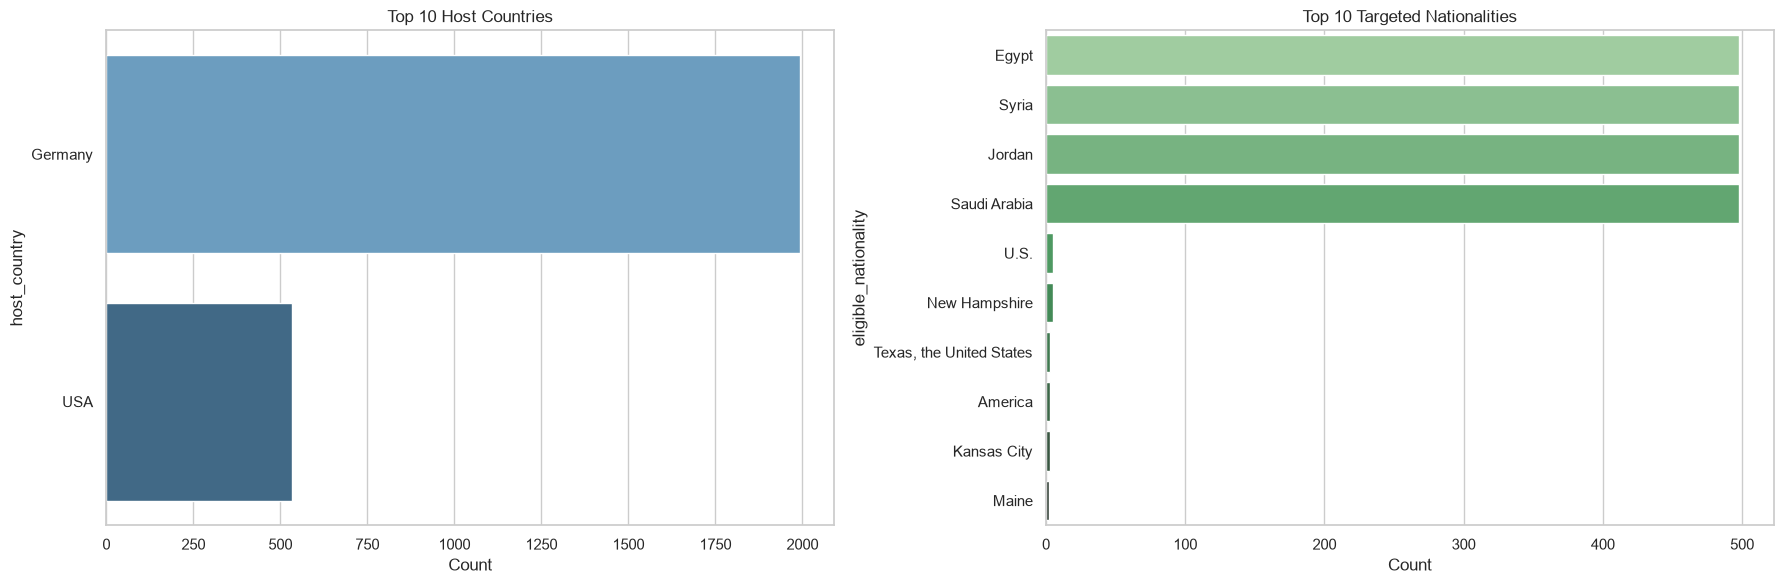

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Top 10 Host Countries
# Exclude 'Unspecified' for a cleaner chart
top_hosts = df_raw[df_raw['host_country'] != 'Unspecified']['host_country'].value_counts().nlargest(10)
sns.barplot(x=top_hosts.values, y=top_hosts.index, ax=axes[0], palette="Blues_d")
axes[0].set_title('Top 10 Host Countries')
axes[0].set_xlabel('Count')

# 2. Top 10 Restricted Eligible Nationalities
# Exclude 'International / All' to see which specific countries are targeted
top_nats = df_raw[df_raw['eligible_nationality'] != 'International / All']['eligible_nationality'].value_counts().nlargest(10)
if not top_nats.empty:
    sns.barplot(x=top_nats.values, y=top_nats.index, ax=axes[1], palette="Greens_d")
    axes[1].set_title('Top 10 Targeted Nationalities')
    axes[1].set_xlabel('Count')
else:
    axes[1].text(0.5, 0.5, 'No Restricted Nationalities Found', horizontalalignment='center', verticalalignment='center')
    axes[1].set_title('Top 10 Targeted Nationalities')

plt.tight_layout()
plt.show()

### deadline

In [ ]:
df_raw['deadline'].value_counts()

deadline
Not Specified                                                                                                                                                                                                                                                                                                                                0.598575
Varies                                                                                                                                                                                                                                                                                                                                       0.020190
May 01, 2027                                                                                                                                                                                                                                                                                                       

In [17]:
import pandas as pd
import requests
import ollama
from src.processing.nlp_extractors import ScholarshipDataProcessor

print(">>> Initializing updated ScholarshipDataProcessor (Ollama Edition)...")
processor = ScholarshipDataProcessor(use_zero_shot=False)

# ---------------------------------------------------------
# NEW: Sanity check to ensure Ollama and Qwen are running
# ---------------------------------------------------------
print(">>> Checking Local LLM Status...")
try:
    response = requests.get("http://localhost:11434/api/tags", timeout=5)
    if response.status_code == 200:
        if 'qwen2.5:7b' in response.text or 'qwen2.5' in response.text:
            print("SUCCESS: Ollama is running and Qwen-2.5 is available.")
        else:
            print("WARNING: Ollama is running, but Qwen-2.5 was not found. Please run: 'ollama run qwen2.5:7b' in terminal.")
    else:
        print(f"WARNING: Ollama returned unexpected status code: {response.status_code}")
except requests.ConnectionError:
    print("ERROR: Ollama is not running! Please open the Ollama application before proceeding.")

# ---------------------------------------------------------
# Execution and Analysis
# ---------------------------------------------------------
print("\n>>> Extracting Deadlines with Hybrid Engine...")
df_raw['standardized_deadline'] = df_raw.progress_apply(processor.process_deadline, axis=1)['standardized_deadline']

# Calculate metrics
total_rows = len(df_raw)
specified = (df_raw['standardized_deadline'] != 'Not Specified').sum()
missing = total_rows - specified

# Print Quality Report
print("\n--- Deadline Extraction Quality Report ---")
print(f"Total Processed: {total_rows}")
print(f"Dates Successfully Standardized: {specified} ({(specified/total_rows)*100:.1f}%)")
print(f"Remaining Missing/Varies: {missing} ({(missing/total_rows)*100:.1f}%)")

# Comprehensive Before & After Analysis
print("\n--- Comprehensive Analysis: Before & After Mapping ---")

# Group by the original deadline and the new standardized deadline to show all variations
mapping_analysis = df_raw.groupby(['deadline', 'standardized_deadline']).size().reset_index(name='frequency_count')

# Sort by frequency to see the most common transformations first
mapping_analysis = mapping_analysis.sort_values(by='frequency_count', ascending=False)

# Set Pandas options to display the full text and more rows for a comprehensive view
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 150)

# Display the complete mapping analysis
display(mapping_analysis)

# Reset Pandas view options to avoid affecting other cells
pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')

INFO: Initializing NLP Models...


>>> Initializing updated ScholarshipDataProcessor (Ollama Edition)...


>>> Checking Local LLM Status...
SUCCESS: Ollama is running and Qwen-2.5 is available.

>>> Extracting Deadlines with Hybrid Engine...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST 


--- Deadline Extraction Quality Report ---
Total Processed: 2526
Dates Successfully Standardized: 1099 (43.5%)
Remaining Missing/Varies: 1427 (56.5%)

--- Comprehensive Analysis: Before & After Mapping ---


,deadline,standardized_deadline,frequency_count
168,Not Specified,Not Specified,1075
150,Not Specified,2023-03-01,53
191,Varies,Not Specified,49
154,Not Specified,2023-07-15,37
128,"May 01, 2027",2027-05-01,33
...,...,...,...
179,"October 28, 2026",2026-10-28,1
176,"October 06, 2026",2026-10-06,1
181,"October 31, 2026",2026-10-31,1
184,"September 15, 2026",2026-09-15,1


In [18]:

mapping_analysis.to_csv("deadline_mapping_grouped.csv", index=False)
print("Saved grouped mapping to: deadline_mapping_grouped.csv")


qa_df = df_raw[['scholarship_name', 'deadline', 'standardized_deadline']]
qa_df.to_csv("deadline_qa_full_comparison.csv", index=False)
print("Saved full row-by-row comparison to: deadline_qa_full_comparison.csv")

Saved grouped mapping to: deadline_mapping_grouped.csv
Saved full row-by-row comparison to: deadline_qa_full_comparison.csv


In [19]:
import textwrap

print(">>> AI Extraction Quality Assurance (QA) Sample <<<\n")

# فلترة المنح التي كانت مفقودة وتم استخراج تاريخ لها بنجاح
recovered_deadlines = df_raw[(df_raw['deadline'].str.lower().isin(['not specified', 'varies'])) & 
                             (df_raw['standardized_deadline'] != 'Not Specified')]

# أخذ 5 عينات عشوائية
qa_sample = recovered_deadlines.sample(5)

for index, row in qa_sample.iterrows():
    print(f" Scholarship: {row['scholarship_name']}")
    print(f" Raw Deadline Column: {row['deadline']}")
    print(f" AI Extracted Date: {row['standardized_deadline']}")
    
    # دمج الوصف كما قرأه النموذج
    context = str(row.get('description', '')) + " " + str(row.get('scholarship_details', ''))
    
    # اقتطاع الوصف وعرض جزء منه لتسهيل القراءة
    short_context = textwrap.shorten(context, width=400, placeholder=" ...")
    print(f" Context Snippet: \n{short_context}")
    print("-" * 80)

>>> AI Extraction Quality Assurance (QA) Sample <<<

 Scholarship: Catholic Academic Exchange Service (KAAD): Eastern Europe Programme (Syria - Undergraduates)
 Raw Deadline Column: Not Specified
 AI Extracted Date: 15-01-2023
 Context Snippet: 
--- Programme Description --- The KAAD is the scholarship institution of the catholic Church in Germany. Applicants for this programme are from Central, Eastern and South-east Europe, the Caucasus and Central Asia [https://www.kaad.de/fileadmin/user_upload/referat-osteuropa/Laenderliste-OE.pdf] , ar... --- Programme Description --- The KAAD is the scholarship institution of the catholic Church ...
--------------------------------------------------------------------------------
 Scholarship: Göttingen Academy of Sciences and Humanities: Hannah Arendt Fellowships (Saudi Arabia - Doctoral candidates/PhD students)
 Raw Deadline Column: Not Specified
 AI Extracted Date: 2026-06-01
 Context Snippet: 
--- Programme Description --- The Hannah Arendt Fe

In [22]:
import pandas as pd

print(">>> Analyzing Expired vs. Active Scholarships <<<\n")

# 1. تحويل عمود التواريخ إلى نوع (Datetime) للتمكن من المقارنة الرياضية
# القيم 'Not Specified' ستتحول تلقائياً إلى NaT (Not a Time)
df_raw['parsed_date'] = pd.to_datetime(df_raw['standardized_deadline'], errors='coerce')

# 2. تحديد تاريخ اليوم للمقارنة
today = pd.Timestamp.now()

# 3. إنشاء عمود 'is_expired' للفلترة المستقبلية في الـ RAG
# إذا كان التاريخ أصغر من اليوم فهو منتهي (True)، غير ذلك فهو (False)
df_raw['is_expired'] = df_raw['parsed_date'] < today

# 4. حساب الإحصائيات
total_rows = len(df_raw)
has_date = df_raw['parsed_date'].notna().sum()
expired_count = (df_raw['parsed_date'] < today).sum()
active_count = (df_raw['parsed_date'] >= today).sum()
missing_count = df_raw['parsed_date'].isna().sum()

# 5. طباعة التقرير
print("--- Deadline Status Report ---")
print(f"Total Scholarships: {total_rows}")
print(f"Without clear dates (Not Specified): {missing_count} ({(missing_count/total_rows)*100:.1f}%)")
print("-" * 30)
print(f"Total with valid dates: {has_date}")
print(f"🔴 Expired / Old Deadlines: {expired_count} ({(expired_count/has_date)*100:.1f}% of dated scholarships)")
print(f"🟢 Active / Future Deadlines: {active_count} ({(active_count/has_date)*100:.1f}% of dated scholarships)")

# عرض عينة للمنح القديمة للتحقق
print("\n--- Sample of Expired Scholarships ---")
display(df_raw[df_raw['is_expired'] == True][['scholarship_name', 'standardized_deadline']].head())

>>> Analyzing Expired vs. Active Scholarships <<<

--- Deadline Status Report ---
Total Scholarships: 2526
Without clear dates (Not Specified): 1456 (57.6%)
------------------------------
Total with valid dates: 1070
🔴 Expired / Old Deadlines: 660 (61.7% of dated scholarships)
🟢 Active / Future Deadlines: 410 (38.3% of dated scholarships)

--- Sample of Expired Scholarships ---


,scholarship_name,standardized_deadline
0,First Presbyterian Church of Shreveport Schola...,2026-05-15
1,Lucile Murray Durkin Scholarship,2026-05-15
2,Harvesters Scholarship Foundation Scholarship,2026-05-31
3,Katie Cannon Scholarship,2026-06-01
4,Robert & Jean Walsh Humanities,2026-06-30


In [23]:
import pandas as pd
import numpy as np

print(">>> Updating Scholarship Status Categorization <<<")

df_raw['parsed_date'] = pd.to_datetime(df_raw['standardized_deadline'], errors='coerce')
today = pd.Timestamp.now()

conditions = [
    df_raw['parsed_date'].isna(),
    df_raw['parsed_date'] < today,
    df_raw['parsed_date'] >= today
]

choices = ['Rolling/Unspecified', 'Expired', 'Active']

df_raw['scholarship_status'] = np.select(conditions, choices, default='Unknown')

status_counts = df_raw['scholarship_status'].value_counts()
print("\n--- Final Status Distribution ---")
print(status_counts.to_string())

print("\nSaved categorization to DataFrame successfully.")

>>> Updating Scholarship Status Categorization <<<

--- Final Status Distribution ---
scholarship_status
Rolling/Unspecified    1456
Expired                 660
Active                  410

Saved categorization to DataFrame successfully.


In [24]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   scholarship_name       2526 non-null   str           
 1   country                2526 non-null   str           
 2   degree_level           2526 non-null   str           
 3   funding_type           2526 non-null   str           
 4   awards_available       2526 non-null   str           
 5   deadline               2526 non-null   str           
 6   tags                   2526 non-null   object        
 7   description            2526 non-null   str           
 8   scholarship_details    2526 non-null   str           
 9   eligibility            2526 non-null   str           
 10  application_process    2526 non-null   str           
 11  application_link       2526 non-null   str           
 12  source_file            2526 non-null   str           
 13  standardized_d

### text_columns

In [3]:
import pandas as pd
import re

print(">>> Running Text Quality Diagnostics for RAG Preparation <<<\n")

text_columns = [
    'scholarship_name', 'description', 'scholarship_details', 
    'eligibility', 'application_process'
]

diagnostic_results = []

for col in text_columns:
    # 1. Check missing or empty strings
    missing_count = df_raw[col].isna().sum() + (df_raw[col].astype(str).str.strip() == '').sum()
    
    # 2. Check for HTML presence
    html_pattern = re.compile(r'<[^>]+>')
    has_html_count = df_raw[col].astype(str).apply(lambda x: bool(html_pattern.search(x))).sum()
    
    # 3. Check for excessive whitespaces or newlines
    whitespace_pattern = re.compile(r'\s{3,}|\n{2,}')
    has_noise_count = df_raw[col].astype(str).apply(lambda x: bool(whitespace_pattern.search(x))).sum()
    
    # 4. Check average word count (to detect useless short texts)
    avg_words = df_raw[col].astype(str).apply(lambda x: len(x.split())).mean()
    
    diagnostic_results.append({
        'Column': col,
        'Missing / Empty': missing_count,
        'Contains HTML': has_html_count,
        'Whitespace Noise': has_noise_count,
        'Avg Word Count': round(avg_words, 1)
    })

diag_df = pd.DataFrame(diagnostic_results)

pd.set_option('display.max_columns', None)
print("--- Text Columns Diagnostic Report ---")
display(diag_df)

>>> Running Text Quality Diagnostics for RAG Preparation <<<

--- Text Columns Diagnostic Report ---


,Column,Missing / Empty,Contains HTML,Whitespace Noise,Avg Word Count
0,scholarship_name,0,0,0,10.7
1,description,24,0,1,48.9
2,scholarship_details,0,24,12,325.7
3,eligibility,36,0,0,76.0
4,application_process,12,0,54,106.9


In [4]:
import pandas as pd
import re

print(">>> Advanced Text Diagnostics Engine (Read-Only) <<<\n")

text_cols = ['description', 'scholarship_details', 'eligibility', 'application_process']
diagnostic_stats = []

# Define regex patterns for structural and whitespace issues
patterns = {
    'broken_bullets': re.compile(r'[•-]\s*\n'),
    'manual_separators': re.compile(r'-{3,}|={3,}|\*{3,}'),
    'excessive_newlines': re.compile(r'\n{3,}'),
    'non_breaking_spaces': re.compile(r'\xa0'),
    'html_tags': re.compile(r'<[^>]+>')
}

dead_text_vals = ['none', 'n/a', 'not specified', 'tba', '']

for col in text_cols:
    stats = {'Column_Name': col}
    
    col_data = df_raw[col].fillna('').astype(str)
    
    stats['Broken_Bullets'] = col_data.apply(lambda x: bool(patterns['broken_bullets'].search(x))).sum()
    stats['Manual_Separators'] = col_data.apply(lambda x: bool(patterns['manual_separators'].search(x))).sum()
    stats['HTML_Tags'] = col_data.apply(lambda x: bool(patterns['html_tags'].search(x))).sum()
    
    stats['Excessive_Newlines'] = col_data.apply(lambda x: bool(patterns['excessive_newlines'].search(x))).sum()
    stats['Non_Breaking_Spaces'] = col_data.apply(lambda x: bool(patterns['non_breaking_spaces'].search(x))).sum()
    
    stats['Dead_Text'] = col_data.apply(lambda x: x.strip().lower() in dead_text_vals or (0 < len(x.strip()) < 15)).sum()
    
    diagnostic_stats.append(stats)

diag_df = pd.DataFrame(diagnostic_stats)

# Check for Redundancy: Description duplicated inside Details
desc_data = df_raw['description'].fillna('').astype(str).str.strip()
details_data = df_raw['scholarship_details'].fillna('').astype(str).str.strip()

overlap_count = 0
for d, det in zip(desc_data, details_data):
    if len(d) > 20 and d in det:
        overlap_count += 1

print("--- Text Quality Diagnostic Report ---")
display(diag_df)

print("\n--- Severe Redundancy Alert ---")
print(f"Total rows where 'description' is completely duplicated inside 'scholarship_details': {overlap_count}")
print(f"Impact: {round((overlap_count/len(df_raw))*100, 1)}% of the dataset suffers from context duplication.")

>>> Advanced Text Diagnostics Engine (Read-Only) <<<

--- Text Quality Diagnostic Report ---


,Column_Name,Broken_Bullets,Manual_Separators,HTML_Tags,Excessive_Newlines,Non_Breaking_Spaces,Dead_Text
0,description,1104,1104,0,0,12,24
1,scholarship_details,1992,1992,24,0,60,232
2,eligibility,1536,1536,0,0,12,674
3,application_process,516,516,0,0,0,1710



--- Severe Redundancy Alert ---
Total rows where 'description' is completely duplicated inside 'scholarship_details': 648
Impact: 25.7% of the dataset suffers from context duplication.
